In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [7]:
import os
os.listdir()

['.config',
 'retail_sales_dataset (1).csv',
 'retail_sales_dataset.csv',
 'sample_data']

In [8]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset (1).csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [12]:
df.columns


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

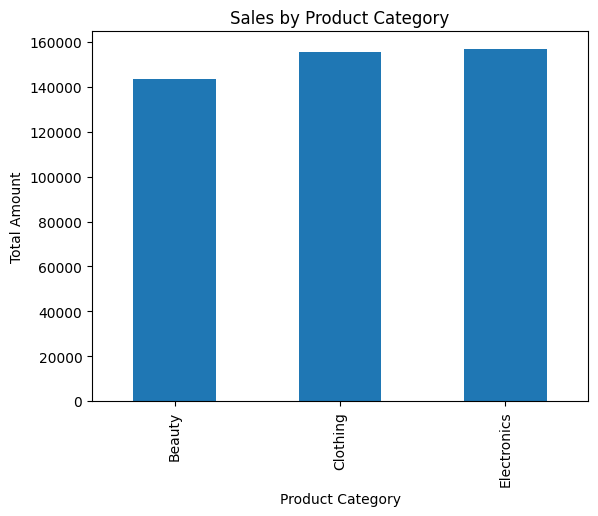

In [13]:
import matplotlib.pyplot as plt

df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

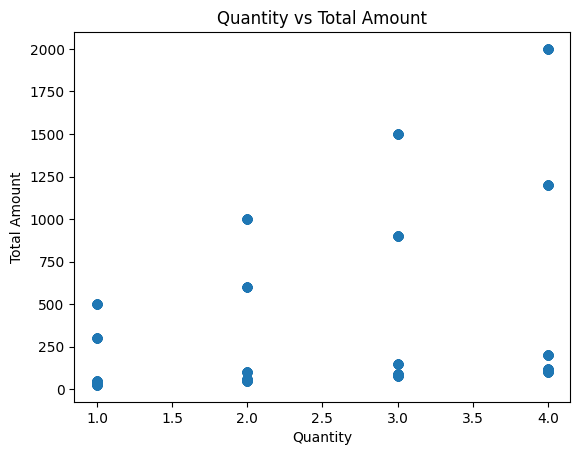

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df["Quantity"], df["Total Amount"])
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

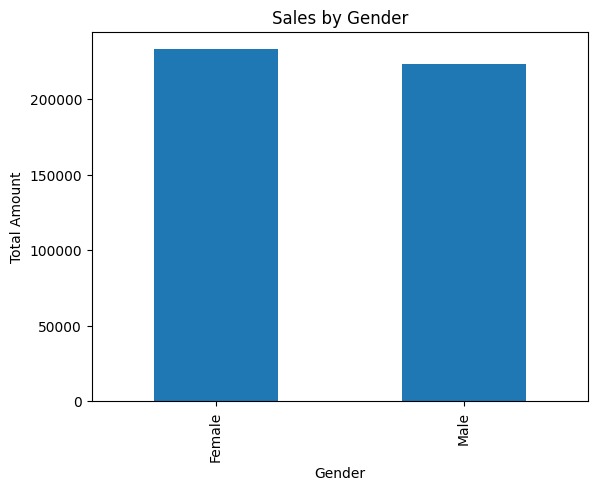

In [15]:
df.groupby("Gender")["Total Amount"].sum().plot(kind="bar")

plt.title("Sales by Gender")
plt.ylabel("Total Amount")
plt.show()

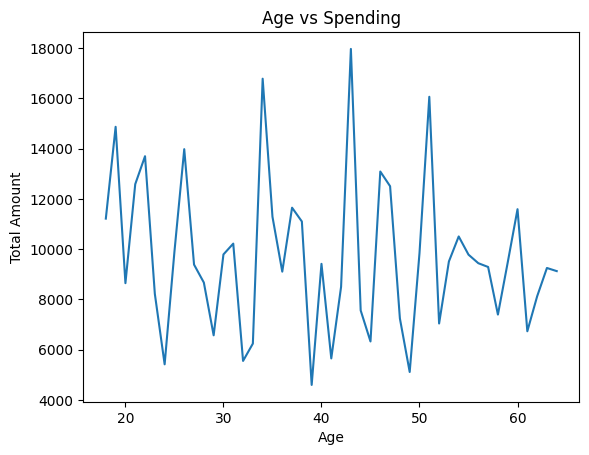

In [16]:
df.groupby("Age")["Total Amount"].sum().plot(kind="line")

plt.title("Age vs Spending")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

In [20]:
df["Month"] = df["Date"].dt.to_period("M")

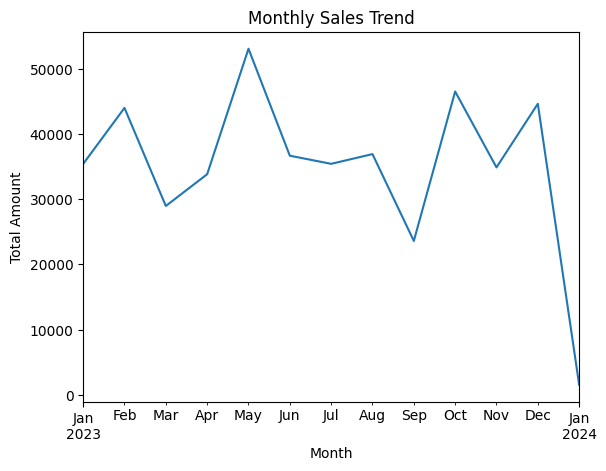

In [21]:
df.groupby("Month")["Total Amount"].sum().plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

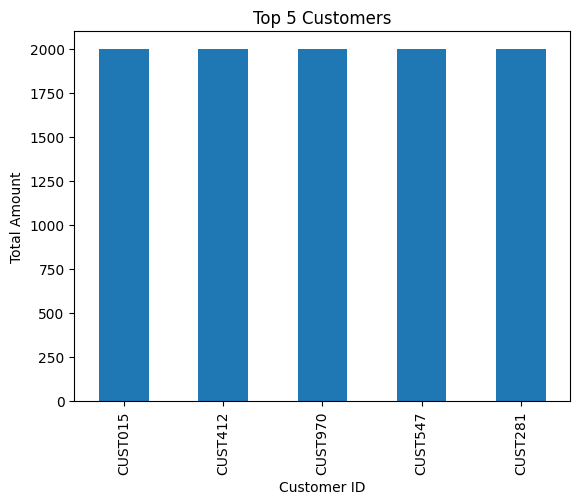

In [22]:
df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(5).plot(kind="bar")

plt.title("Top 5 Customers")
plt.ylabel("Total Amount")
plt.show()

In [23]:
print("Total Sales:", df["Total Amount"].sum())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Products:", df["Product Category"].nunique())

Total Sales: 456000
Total Customers: 1000
Total Products: 3


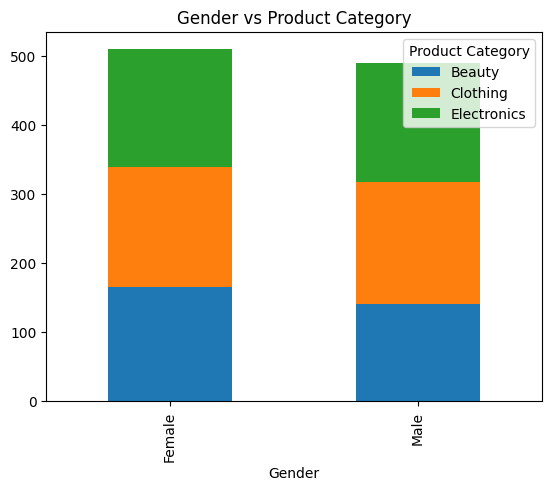

In [25]:
import pandas as pd

pd.crosstab(df["Gender"], df["Product Category"]).plot(kind="bar", stacked=True)

plt.title("Gender vs Product Category")
plt.show()

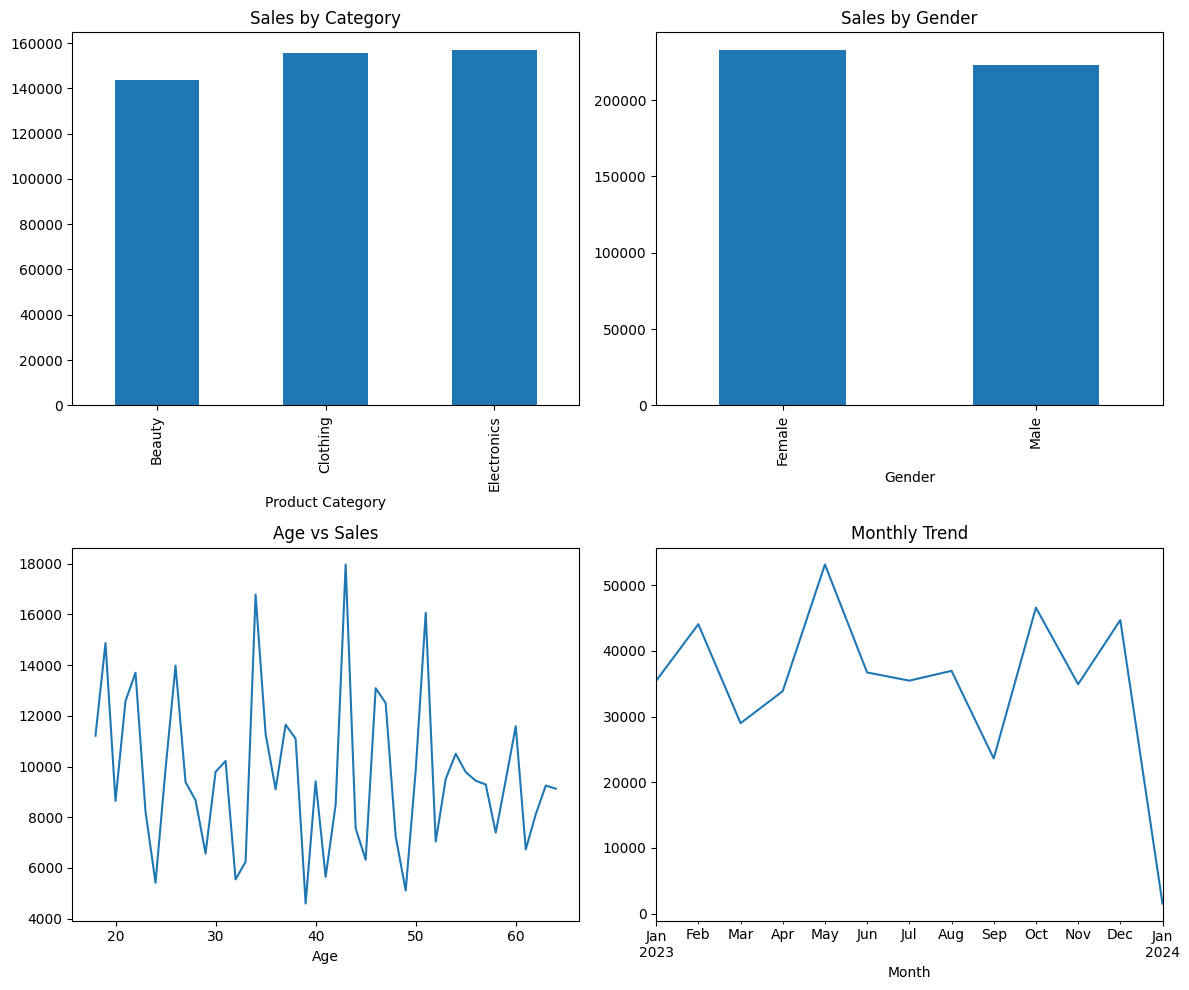

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Sales by Category")

df.groupby("Gender")["Total Amount"].sum().plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Sales by Gender")

df.groupby("Age")["Total Amount"].sum().plot(kind="line", ax=axes[1,0])
axes[1,0].set_title("Age vs Sales")

df.groupby("Month")["Total Amount"].sum().plot(kind="line", ax=axes[1,1])
axes[1,1].set_title("Monthly Trend")

plt.tight_layout()
plt.show()